# Chapter 105 — Periodic Motion

> **Prerequisites:** ch104 (Wave Functions)
>
> **Outcomes:** Model oscillating systems with sinusoids; Simulate simple harmonic motion; Understand damping and resonance


## Simple Harmonic Motion

A mass on a spring satisfies: d²x/dt² = -ω²x,  ω² = k/m

Solution: x(t) = A·cos(ωt + φ)

This is the most important oscillator in physics — it appears in:
- Pendulums (small angle), springs, LC circuits, molecular vibrations
- Sound: each frequency is a harmonic oscillator
- Quantum mechanics: harmonic oscillator is the foundational model

**Energy:** E = ½kA² — constant for undamped oscillation
**Damped oscillator:** x(t) = A·e^(-γt)·cos(ωt + φ)
The amplitude decays exponentially while oscillating.

C:\Users\user\AppData\Local\Temp\ipykernel_22712\1573415819.py:48: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


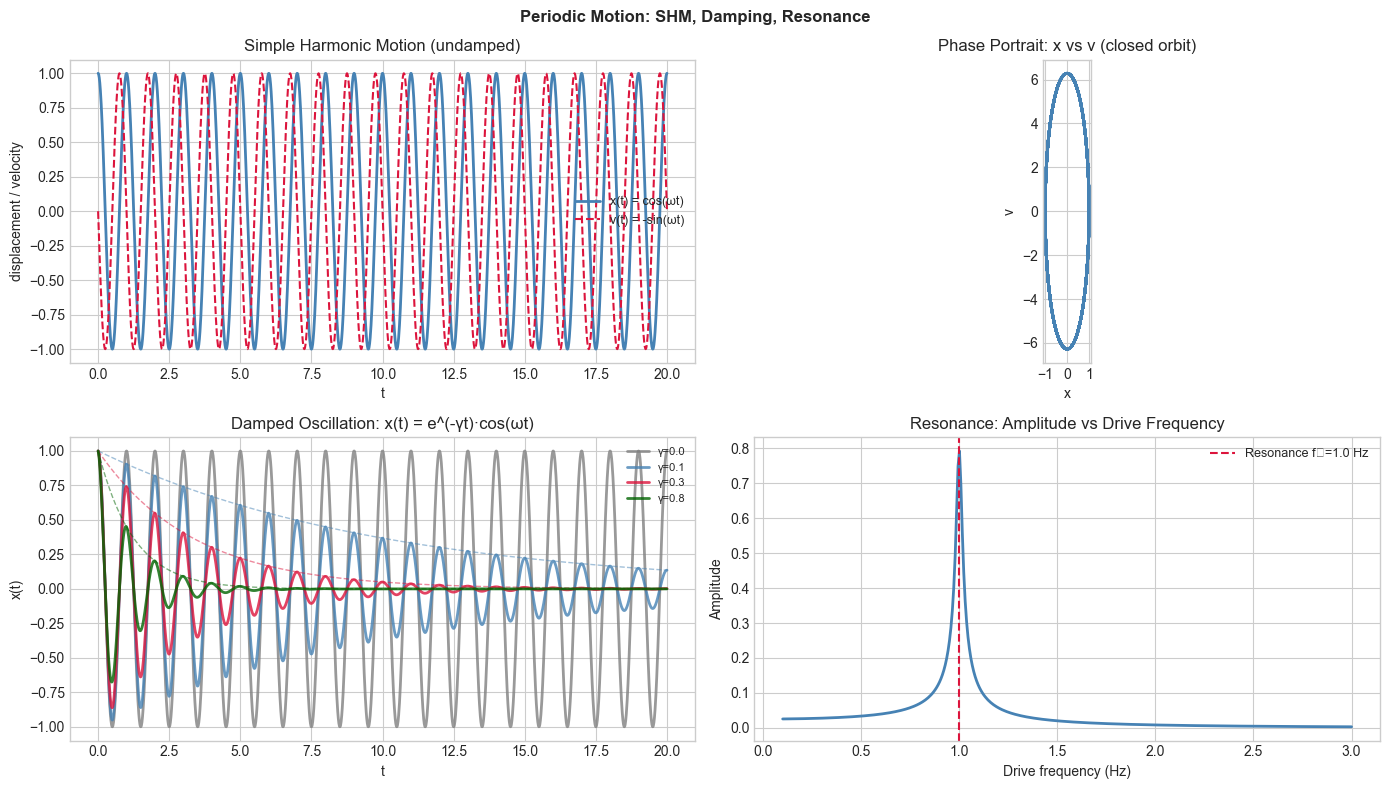

In [2]:
# --- Oscillator simulation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

t = np.linspace(0, 20, 2000)
omega = 2*np.pi  # angular frequency = 1 Hz
A = 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Undamped
axes[0,0].plot(t, A*np.cos(omega*t), 'steelblue', lw=2, label='x(t) = cos(ωt)')
axes[0,0].plot(t, -A*omega*np.sin(omega*t)/omega, 'crimson', lw=1.5, linestyle='--', label='v(t) = -sin(ωt)')
axes[0,0].set_title('Simple Harmonic Motion (undamped)'); axes[0,0].legend(fontsize=9)
axes[0,0].set_xlabel('t'); axes[0,0].set_ylabel('displacement / velocity')

# Phase portrait: position vs velocity
x_undamp = A*np.cos(omega*t)
v_undamp = -A*omega*np.sin(omega*t)
axes[0,1].plot(x_undamp, v_undamp, 'steelblue', lw=2)
axes[0,1].set_title('Phase Portrait: x vs v (closed orbit)'); axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('v')
axes[0,1].set_aspect('equal')

# Damped oscillation
for gamma, color in [(0.0,'gray'),(0.1,'steelblue'),(0.3,'crimson'),(0.8,'darkgreen')]:
    x_damp = A * np.exp(-gamma*t) * np.cos(omega*t)
    axes[1,0].plot(t, x_damp, color=color, lw=2, alpha=0.8, label=f'γ={gamma}')
    if gamma > 0:
        axes[1,0].plot(t, A*np.exp(-gamma*t), color=color, lw=1, linestyle='--', alpha=0.5)
axes[1,0].set_title('Damped Oscillation: x(t) = e^(-γt)·cos(ωt)'); axes[1,0].legend(fontsize=8)
axes[1,0].set_xlabel('t'); axes[1,0].set_ylabel('x(t)')

# Resonance: driven oscillator
omega_0 = 2*np.pi  # natural frequency
omega_drive_vals = np.linspace(0.1*omega_0, 3*omega_0, 400)
gamma_r = 0.1

# Amplitude response: x_amp = F0 / sqrt((ω0²-ωd²)² + (2γωd)²)
F0 = 1
amp = F0 / np.sqrt((omega_0**2 - omega_drive_vals**2)**2 + (2*gamma_r*omega_drive_vals)**2)
axes[1,1].plot(omega_drive_vals/(2*np.pi), amp, 'steelblue', lw=2)
axes[1,1].axvline(omega_0/(2*np.pi), color='crimson', linewidth=1.5, linestyle='--', label=f'Resonance f₀={omega_0/(2*np.pi):.1f} Hz')
axes[1,1].set_title('Resonance: Amplitude vs Drive Frequency'); axes[1,1].legend(fontsize=9)
axes[1,1].set_xlabel('Drive frequency (Hz)'); axes[1,1].set_ylabel('Amplitude')

plt.suptitle('Periodic Motion: SHM, Damping, Resonance', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- SHM: x(t) = A·cos(ωt+φ) — the universal small-oscillation solution
- Damped: amplitude decays as e^(-γt) while oscillating
- Resonance: maximum amplitude when drive frequency matches natural frequency
- Every sinusoidal function is modeling some oscillating system

**Forward:** Full ODE treatment in ch225; resonance connects to eigenvalues in ch172.